In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
import io
data = pd.read_csv('final_merged_dataset.csv')

In [20]:
data.head()

,CropDays,SoilMoisture,temperature,humidity,Irrigation,N,P,K,ph,rainfall,label
0,5,345,21,55,0,10,79,18,5.624731,184.622671,pigeonpeas
1,13,659,26,40,1,7,56,23,5.545219,55.504292,mothbeans
2,45,201,23,19,0,37,65,16,5.683548,63.592767,kidneybeans
3,45,201,23,19,0,22,80,20,5.669561,100.118612,kidneybeans
4,57,238,21,16,0,34,76,80,7.985417,65.238111,chickpea


In [21]:
print(data['label'].unique())

['pigeonpeas' 'mothbeans' 'kidneybeans' 'chickpea' 'blackgram' 'maize'
 'mango' 'coffee' 'lentil' 'grapes' 'rice']


In [22]:
print(data.groupby('label').size())

label
blackgram       4
chickpea       31
coffee          9
grapes         11
kidneybeans    39
lentil         51
maize          60
mango           6
mothbeans      17
pigeonpeas     24
rice            1
dtype: int64


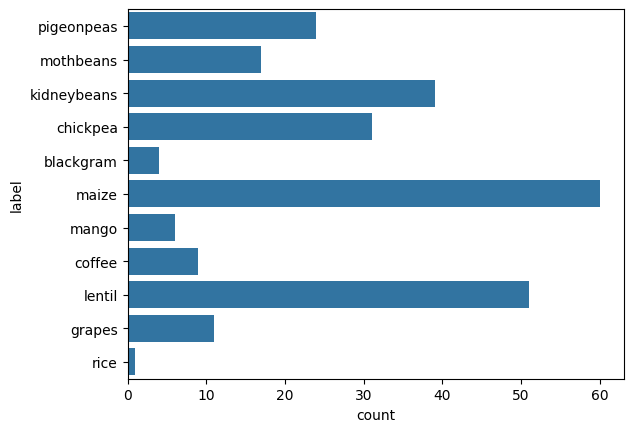

In [23]:
sns.countplot(data['label'],label='count')
plt.show()

In [24]:
from pandas.plotting import scatter_matrix
Y = data['Irrigation']  # Target variable
X = data.drop(columns=['Irrigation'])

C:\Users\rensi\AppData\Local\Temp\ipykernel_3380\1689908663.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gnuplot')


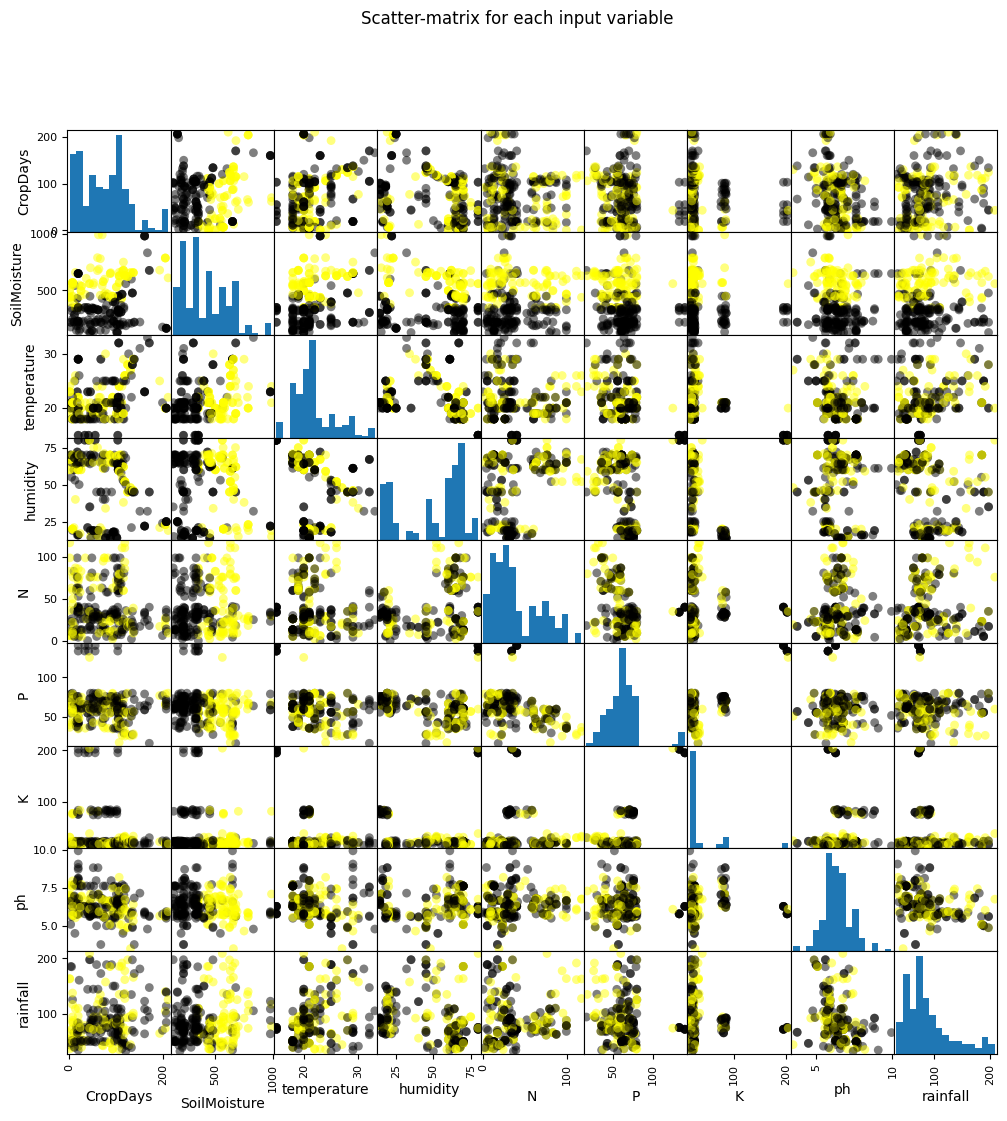

In [25]:
from pandas.plotting import scatter_matrix
from matplotlib import cm
Components = ['CropDays', 'SoilMoisture', 'temperature', 'humidity', 'N', 'P', 'K', 'ph', 'rainfall']
X = data[Components]
y = data['Irrigation']
cmap = cm.get_cmap('gnuplot')
scatter = pd.plotting.scatter_matrix(
    X, c=y, marker='o', s=40, hist_kwds={'bins': 15}, figsize=(12, 12), cmap=cmap
)
plt.suptitle('Scatter-matrix for each input variable')
plt.savefig('crop_scatter_matrix.png')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size = 0.2, random_state = 0)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
def collect_metrics(model_name, y_test, y_pred):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='binary'),
        'Recall': recall_score(y_test, y_pred, average='binary'),
        'F1-Score': f1_score(y_test, y_pred, average='binary')
    }

# Initialize an empty list to store metrics
model_performance = []

In [28]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier().fit(X_train, Y_train)


In [29]:
Y_pred = clf.predict(X_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[32  2]
 [ 1 16]]


In [30]:
from sklearn.metrics import classification_report
print("Decision Tree Classification Report:\n", classification_report(Y_test, Y_pred))

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96        34
           1       0.89      0.94      0.91        17

    accuracy                           0.94        51
   macro avg       0.93      0.94      0.93        51
weighted avg       0.94      0.94      0.94        51



In [31]:
model_performance.append(collect_metrics("Decision Tree", Y_test, Y_pred))

In [32]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)


KNeighborsClassifier()

In [33]:
Y_pred = knn.predict(X_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[29  5]
 [ 3 14]]


In [34]:
from sklearn.metrics import classification_report
print("K-Nearest Neighbors Classification Report:\n", classification_report(Y_test, Y_pred))

K-Nearest Neighbors Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.85      0.88        34
           1       0.74      0.82      0.78        17

    accuracy                           0.84        51
   macro avg       0.82      0.84      0.83        51
weighted avg       0.85      0.84      0.85        51



In [35]:
model_performance.append(collect_metrics("KNN", Y_test, Y_pred))

In [36]:
#Gauss Naive Bayes
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, Y_train)


GaussianNB()

In [37]:
Y_pred = gnb.predict(X_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[22 12]
 [ 2 15]]


In [38]:
from sklearn.metrics import classification_report
print("Gaussian Naive Bayes Classification Report:\n", classification_report(Y_test, Y_pred))

Gaussian Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.65      0.76        34
           1       0.56      0.88      0.68        17

    accuracy                           0.73        51
   macro avg       0.74      0.76      0.72        51
weighted avg       0.80      0.73      0.73        51



In [39]:
model_performance.append(collect_metrics("Naive Bayes", Y_test, Y_pred))


In [40]:
#SVM
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, Y_train)


SVC()

In [41]:
Y_pred = svm.predict(X_test)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[31  3]
 [ 1 16]]


In [42]:
from sklearn.metrics import classification_report
print("Support Vector Machine Classification Report:\n", classification_report(Y_test, Y_pred))

Support Vector Machine Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.91      0.94        34
           1       0.84      0.94      0.89        17

    accuracy                           0.92        51
   macro avg       0.91      0.93      0.91        51
weighted avg       0.93      0.92      0.92        51



In [43]:
model_performance.append(collect_metrics("SVM", Y_test, Y_pred))

In [47]:
performance_df = pd.DataFrame(model_performance)

# Display the performance table
print(performance_df)


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.941176   0.888889  0.941176  0.914286
1            KNN  0.843137   0.736842  0.823529  0.777778
2    Naive Bayes  0.725490   0.555556  0.882353  0.681818
3            SVM  0.921569   0.842105  0.941176  0.888889


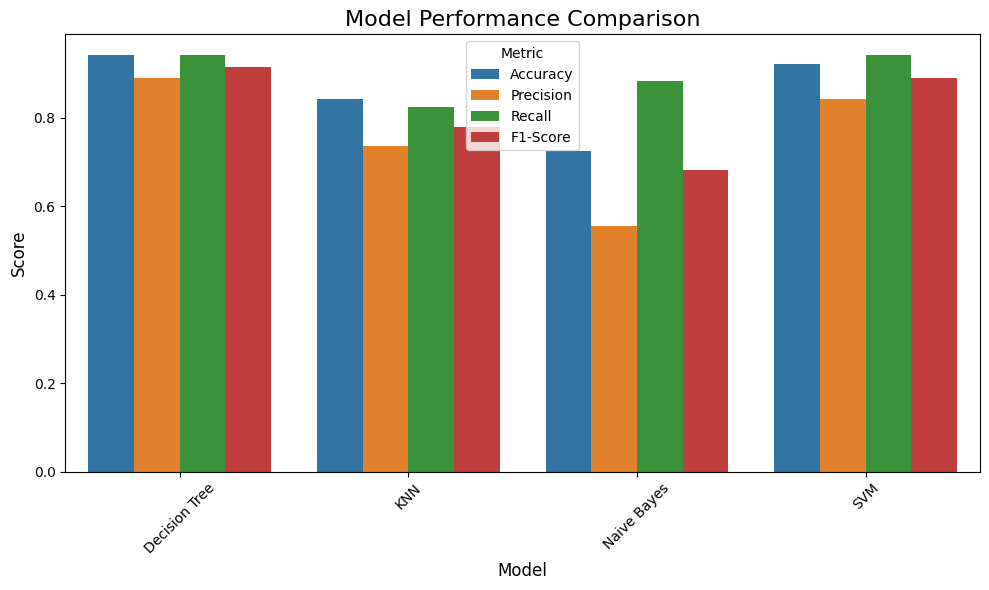

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming performance_df already exists with the model performance data
# Example of the DataFrame (if it's already like this):
#    Model          Accuracy  Precision    Recall  F1-Score
# 0  Decision Tree  0.950495   0.911765  0.939394  0.925373
# 1  KNN            0.980198   0.942857  1.000000  0.970588
# 2  Naive Bayes    0.891089   0.843750  0.818182  0.830769
# 3  SVM            0.940594   0.935484  0.878788  0.906250
# 4  Neural Network 0.673267   0.000000  0.000000  0.000000

# Reshape the DataFrame for plotting
performance_melted = performance_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Set the figure size
plt.figure(figsize=(10, 6))

# Plot a bar chart using seaborn
sns.barplot(x="Model", y="Score", hue="Metric", data=performance_melted)

# Set plot labels and title
plt.title("Model Performance Comparison", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()


In [49]:
import joblib

# Assuming your model is named 'svm'
joblib.dump(clf, 'DT_model.pkl')

['DT_model.pkl']